# LDH Adsorption – RR % all-features run (incl. LightGBM)
Successor of `Scaled_ldh_adsorption_analysis.ipynb`, on the primary interpolation protocol, adding **LightGBM** to the model zoo.

> **Why there is no separate "scaled" experiment anymore:** scaling now happens *inside* each model's pipeline — LR/KNN/ANN/Cubist get a StandardScaler, tree models (RF/XGB/HistGB/LGB) are scale-invariant and don't need one. The old scaled/unscaled notebook pair never actually delivered the distinction (the scaled frame was overwritten before training, and the "unscaled" one left five imputed columns z-scored).

> **Scope of the claim.** The dataset's 1342 rows come from **59 source studies**: within one
> study, the material and pollutant descriptors are constant and only the operating conditions
> (pH, temperature, time, dosage, Ci) vary. These models are therefore trained and validated to
> **predict RR % for *studied* material–pollutant systems at new operating conditions**
> (within-system interpolation, row-level split with exact-duplicate rows removed).
> They are **not** validated for screening unseen materials or pollutants: a grouped split by
> source study (reported in the main notebook as a limitation analysis) shows near-zero
> cross-study R². Do not cite the interpolation metrics as evidence of screening power.

> **Methodology notes (rewrite, 2026-09):** rebuilt on the shared
> [`ldh_pipeline.py`](ldh_pipeline.py) module after a code review. Scores are reported as three
> honestly-labeled numbers (train / CV validation / hold-out test); KNN imputation, scaling and
> encoding live inside each model's Pipeline (fit on training folds only); RR % is normalized
> range-aware to [0, 100]; exact feature-duplicate rows are removed before splitting; every
> split, CV fold, and Optuna sampler is seeded; each experiment saves models + scores + config
> under its own `Model/<experiment_name>/` folder.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
# On Colab: clone/mount the repo and point this at its notebooks/ folder.
sys.path.insert(0, str(Path.cwd()))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ldh_pipeline as lp

plt.rcParams.update({
    'figure.facecolor': '#F8F9FA', 'axes.facecolor': '#FAFAFA',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titleweight': 'bold', 'axes.titlesize': 12,
})
SEED = lp.SEED
print('Data dir :', lp.DATA_DIR)
print('Model dir:', lp.MODEL_DIR)

Data dir : /home/trunght/workspace/researches/Green-X Project-BaoTien/Data
Model dir: /home/trunght/workspace/researches/Green-X Project-BaoTien/Model


In [2]:
df = lp.load_data(lp.DATA_DIR / '20260804_Data_Adsorption.xlsx')
cfg = lp.ExperimentConfig(name='all_features_lgb_interp_42', split_mode='row',
                          dedup_features=True,
                          models=("LR", "KNN", "ANN", "Cubist", "RF", "XGB", "HistGB", "LGB"))
run = lp.run_experiment(cfg, df)
run['table'].round(3)

[all_features_lgb_interp_42] dropped 83 exact feature-duplicate rows
[all_features_lgb_interp_42] split=row  train=1007  test=252  features=30
--- Optuna tuning RF (30 trials) ---


[*] RF best params: {'n_estimators': 347, 'max_depth': 13, 'min_samples_leaf': 3}
--- Optuna tuning XGB (30 trials) ---


[*] XGB best params: {'n_estimators': 495, 'learning_rate': 0.11367160721608166, 'max_depth': 13, 'min_child_weight': 7}
--- Optuna tuning HistGB (30 trials) ---


[*] HistGB best params: {'max_iter': 484, 'learning_rate': 0.08868791876058112, 'max_depth': 14, 'min_samples_leaf': 8}
--- Optuna tuning LGB (30 trials) ---


[*] LGB best params: {'n_estimators': 317, 'learning_rate': 0.11359733747889753, 'max_depth': 9, 'min_child_samples': 7}
--- LR ---


...

    Train      R2  0.9029 | MAE   5.7435
    CV (valid) R2  0.7715 | MAE   9.1184
    Test       R2  0.8007 | MAE   8.3489

--- XGB ---


    Train      R2  0.9935 | MAE   0.8263
    CV (valid) R2  0.8377 | MAE   6.9046
    Test       R2  0.8739 | MAE   5.4642

--- HistGB ---


    Train      R2  0.9905 | MAE   1.5252
    CV (valid) R2  0.8416 | MAE   6.8528
    Test       R2  0.8638 | MAE   5.6192

--- LGB ---


    Train      R2  0.9844 | MAE   1.9500
    CV (valid) R2  0.8428 | MAE   6.8755
    Test       R2  0.8749 | MAE   5.7917



,train_r2,cv_r2,test_r2,train_mae,cv_mae,test_mae,test_rmse
XGB,0.994,0.838,0.874,0.826,6.905,5.464,10.025
HistGB,0.991,0.842,0.864,1.525,6.853,5.619,10.417
LGB,0.984,0.843,0.875,1.950,6.875,5.792,9.985
KNN,0.996,0.731,0.758,0.082,8.031,7.728,13.879
Cubist,0.925,0.780,0.792,4.343,8.597,8.102,12.873
RF,0.903,0.771,0.801,5.744,9.118,8.349,12.601
ANN,0.609,0.506,0.569,13.272,15.174,14.106,18.525
LR,0.440,0.376,0.439,16.909,17.653,17.225,21.145


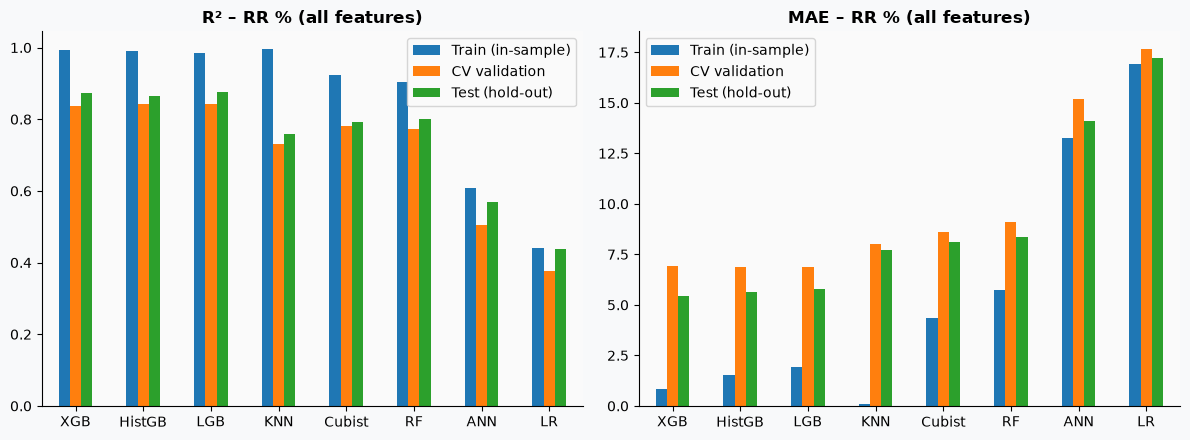

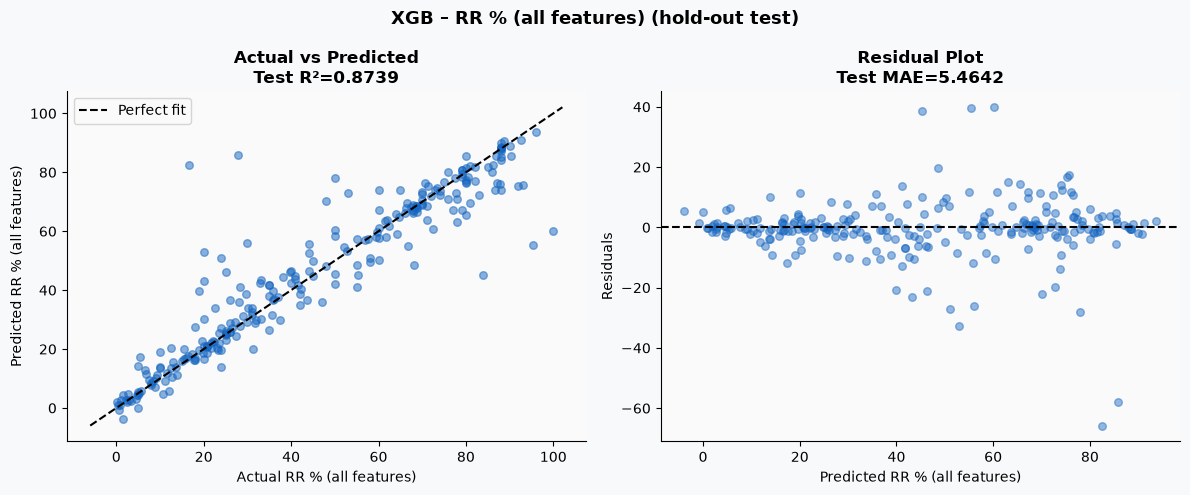

In [3]:
lp.plot_model_comparison(run['table'], 'RR % (all features)',
                         out_path=run['out_dir'] / 'model_results.png')
best = run['table'].index[0]
lp.plot_parity(run['results'][best], 'RR % (all features)',
               out_path=run['out_dir'] / 'best_model_parity.png')

In [4]:
ranks = lp.permutation_ranks(run['results'], run['X_test'], run['y_test'])
ranks.to_csv(run['out_dir'] / 'permutation_importance.csv')
ranks.sort_values('LGB')

,LR,KNN,ANN,Cubist,RF,XGB,HistGB,LGB
AD g/L,27,1,29,1,1,1,1,1
Time h,19,3,1,2,2,2,2,2
Ci mg/L,22,4,14,3,3,4,3,3
pH,25,2,4,5,7,5,4,4
Log Kow,11,9,16,18,5,3,7,5
BET m2/g,24,5,2,7,6,6,6,6
pHpzc,26,7,19,9,4,7,5,7
average Pauling electronegativity,15,13,7,15,9,9,8,8
APD nm,29,8,22,12,10,13,11,9
PV cm3/g,10,16,12,4,8,10,9,10
